In [7]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score,mean_squared_error
import seaborn as sns 

In [2]:
insurance=pd.read_csv("insurance.csv")


X=insurance.drop(columns=["charges"])
y=insurance["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype="int")

X["smoker"]=X["smoker"].map({"yes":1,"no":0})
X["sex"]=X["sex"].map({"female":1,"male":0})

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


mean square error for alpha0.01 is  33597370.842884876
mean square error for alpha0.1 is  33601489.864824
mean square error for alpha2 is  33698329.32865227
mean square error for alpha3 is  33756607.3129378
mean square error for alpha4 is  33819692.188391715
mean square error for alpha5 is  33887411.24910422
mean square error for alpha10 is  34289876.70984791
mean square error for alpha20 is  35358225.10326675
mean square error for alpha30 is  36683726.75626456
mean square error for alpha40 is  38181663.1560663
mean square error for alpha50 is  39790870.73791458
mean square error for alpha100 is  48311750.05326996


<Axes: >

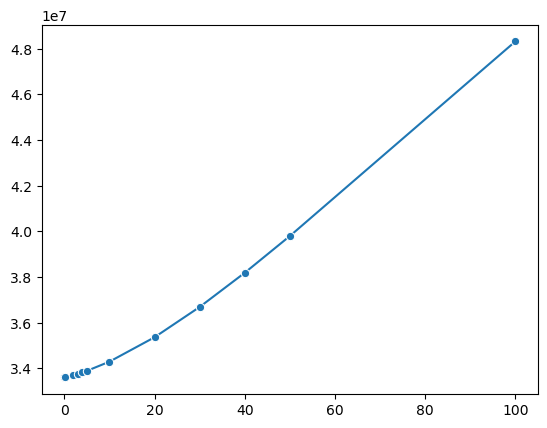

In [9]:
alphas=[0.01,0.1,2,3,4,5,10,20,30,40,50,100]
mses=[]
for a in alphas:
        
    ridge_model=Ridge(alpha=a)
    ridge_model.fit(X_train,y_train)

    y_pred=ridge_model.predict(X_test)

    mse_value=mean_squared_error(y_test,y_pred)
    print(f"mean square error for alpha{a} is ",mse_value)
    mses.append(mse_value)

sns.lineplot(x=alphas,y=mses,marker="o")

In [15]:
from sklearn.linear_model import RidgeCV
Ridge_cv_model = RidgeCV(
    alphas=[0.001,0.01,0.1,1,2,5,10,20,30,40,50,100],
    cv=5
)

Ridge_cv_model.fit(X_train,y_train)

print("Best Alpha:",Ridge_cv_model.alpha_)

y_pred=Ridge_cv_model.predict(X_test)

r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
print("mse=",mse)
print("r2=",r2)

Best Alpha: 1.0
mse= 33645037.09177903
r2= 0.7832830144988214


In [19]:
ridge_model=Ridge(alpha=1)
ridge_model.fit(X_train,y_train)

y_pred=ridge_model.predict(X_test)

mse_value=mean_squared_error(y_test,y_pred)
print(f"mean square error for alpha{a} is ",mse_value)


mean square error for alpha100 is  33645037.09177903
